In [66]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
import numpy as np
import torch
torch.set_default_dtype(torch.float64)

from scipy.special import logit
from matplotlib import pyplot as plt

In [68]:
import sys
import os
sys.path.append(os.path.abspath('/Users/thierryrioual/Desktop/Princeton/Academics/Research/implementation'))

from src.config import DataConfig, AlgorithmConfig

from src.dgp import IsotropicGaussian
from src.asymptotics import MacroscopicStateEvolution
from src.algorithms import SelfTrainedGradientDescent
from src.callbacks import TestEvaluatorCallback

from scripts.runner import MonteCarloExperiment

In [69]:
def signal_prior(seed: int = None) -> float:
    """
    A deterministic function mapping (seed, index) pairs to a normal distribution.
    If seed is None, it acts like a standard random sampler.
    """
    if seed is None:
        return torch.normal(mean=1.0, std=1.0, size=(1,)).item()
    rng = torch.Generator().manual_seed(seed)
    return torch.normal(mean=1.0, std=1.0, size=(1,), generator=rng).item()

In [76]:
data_cfg = DataConfig(
    scale=1.0,
    label_prior=0.2,
    observation_prior=0.01,
    data_to_dimension_ratio=20.0,
    signal_prior=signal_prior,  
)

data = IsotropicGaussian(
    cfg=data_cfg, 
    n_train=10000,
    n_test=5000,
    dimensions=500,
    seed=42
)

In [77]:
X_lab, Y_lab, X_unl, Y_unl, X_test, Y_test = data.sample()

In [78]:
callback = TestEvaluatorCallback(
    X_lab=X_lab,
    Y_lab=Y_lab,
    X_unl=X_unl, 
    Y_unl=Y_unl,
    X_test=X_test, 
    Y_test=Y_test,
    mu=data._mu,
    metrics={
        "lab_error", "unl_error", "test_error", "unl_usage", "weight_signal_alignment", "weight_vector_norm", "bias_term"
    }
)

algorithm_cfg = AlgorithmConfig(
    n_iterations=2000,
    ramp_start=500,
    ramp_end=1000,
    margin_threshold=logit(0.9),
    penalty_param=0.1,
    step_size=0.1,
    pseudo_label_param=20.0,
    include_bias=False
)

st = SelfTrainedGradientDescent(cfg=algorithm_cfg, callback=callback)

In [79]:
b, w = st.fit(X_lab, Y_lab, X_unl)

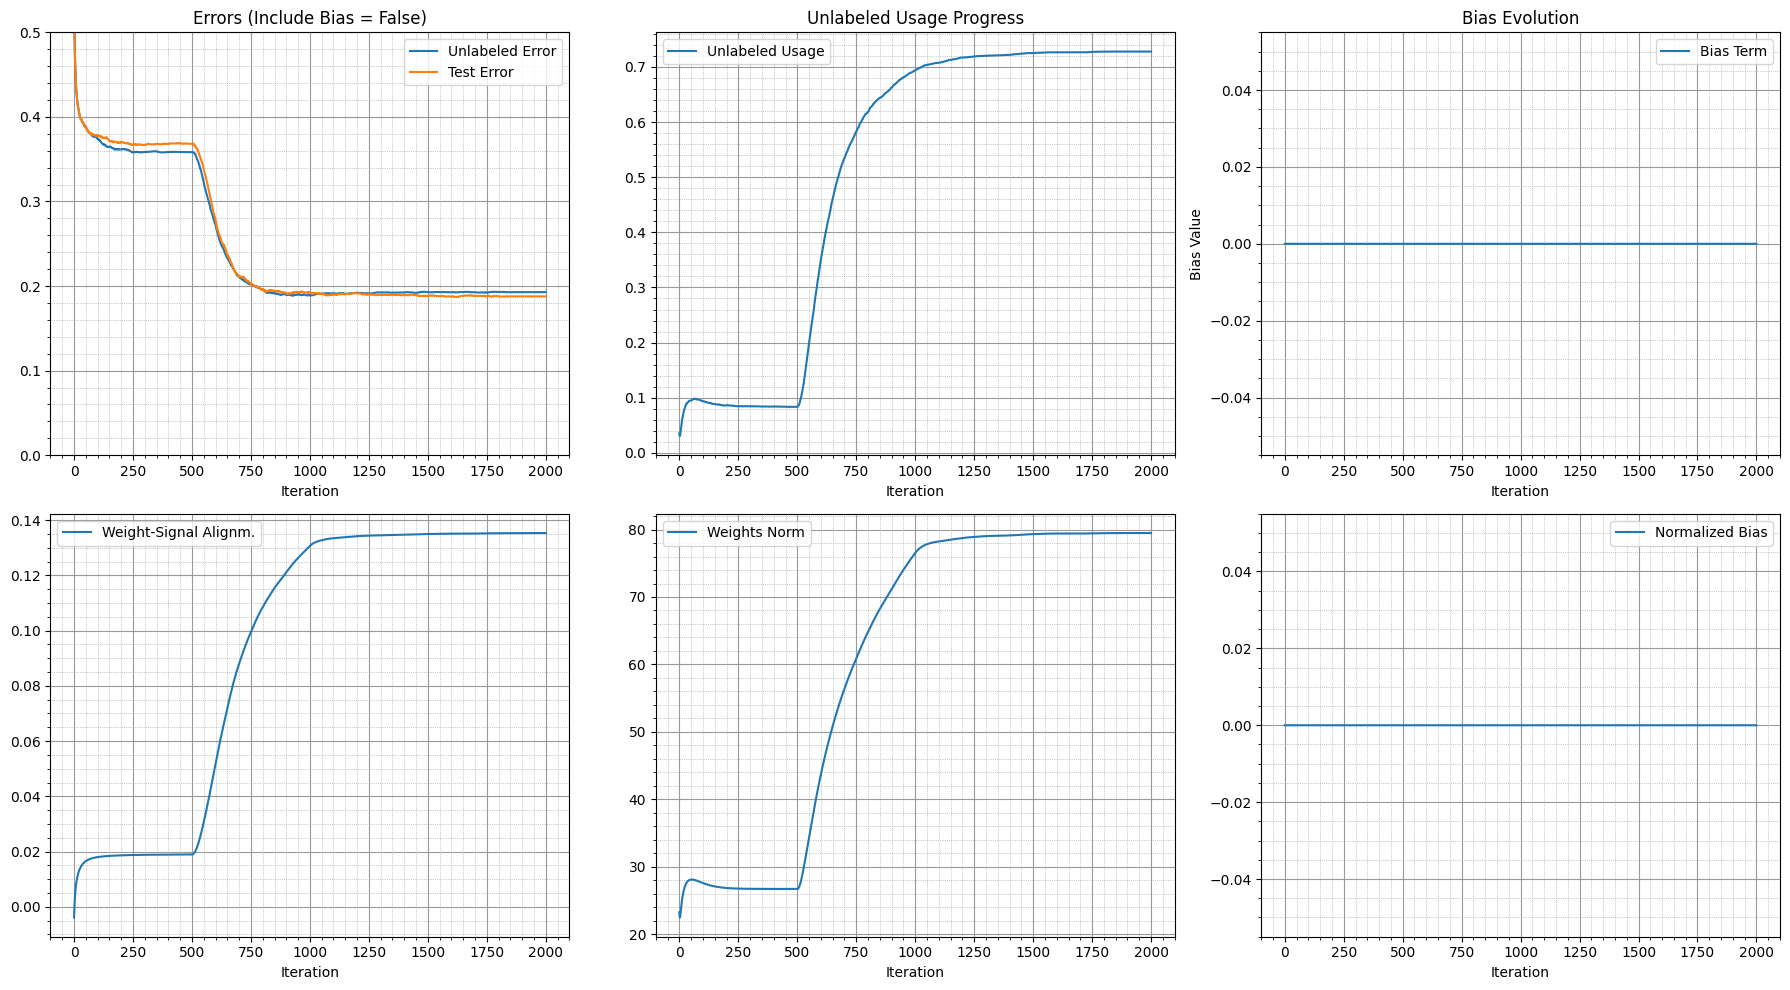

In [80]:
# Create a 1x3 grid of subplots side-by-side
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- Plot 1: Errors ---
axes[0, 0].plot(callback.history_["unl_error"], label='Unlabeled Error')
axes[0, 0].plot(callback.history_["test_error"], label='Test Error')
axes[0, 0].set_ylim(0, 0.5)
axes[0, 0].set_title(f'Errors (Include Bias = {st.cfg.include_bias})')

# --- Plot 2: Unlabeled Usage ---
axes[0, 1].plot(callback.history_["unl_usage"], label='Unlabeled Usage')
axes[0, 1].set_title('Unlabeled Usage Progress')

# --- Plot 3: Bias Term ---
axes[0, 2].plot(callback.history_["bias_term"], label='Bias Term')
axes[0, 2].set_ylabel('Bias Value') 
axes[0, 2].set_title('Bias Evolution')

# --- Plot 4
axes[1, 0].plot(callback.history_["weight_signal_alignment"], label="Weight-Signal Alignm.")

axes[1, 1].plot(callback.history_["weight_vector_norm"], label="Weights Norm")

normalized_bias = np.array(callback.history_["bias_term"]) / np.array(callback.history_["weight_vector_norm"])
axes[1, 2].plot(normalized_bias, label="Normalized Bias")


# --- Apply Common Styling to All Subplots ---
for ax in axes.flatten():
    ax.set_xlabel('Iteration')
    ax.legend()
    ax.grid(which='major', color='#999999', linestyle='-', linewidth=0.8)
    ax.grid(which='minor', color='#999999', linestyle=':', linewidth=0.5)
    ax.minorticks_on()

# Adjust spacing so labels don't overlap, then show
plt.tight_layout()
plt.show()

In [87]:
from IPython.core.magics import config
runs = 10
monte_carlo_seeds = list(range(runs))
N = 100
M = 10000
N_test = 5000

mc_cfg = AlgorithmConfig(
    n_iterations=500,
    ramp_start=200,
    ramp_end=250,
    margin_threshold=logit(0.9),
    penalty_param=0.1,
    step_size=0.1,
    pseudo_label_param=20.0,
    include_bias=False
)

mc = MonteCarloExperiment(
    data_gen=data, 
    algorithm=SelfTrainedGradientDescent, 
    base_config=mc_cfg
)

In [ ]:
target_param = 'margin_threshold'
test_values = [logit(v) for v in [0.6, 0.75, 0.9, 0.99]]

mc.run_sweep(
    seeds=monte_carlo_seeds, 
    sweep_param_name=target_param, 
    sweep_param_values=test_values
)

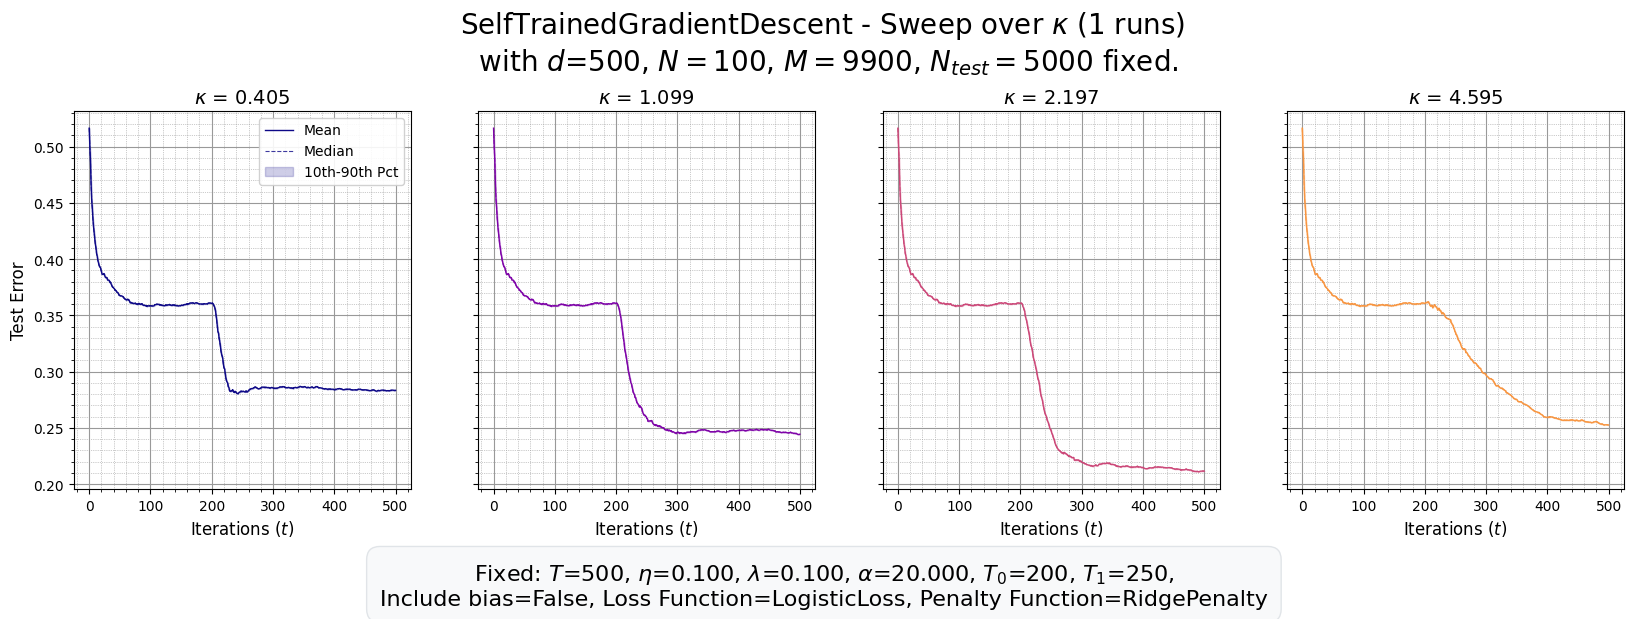

In [86]:
mc.plot_trajectories(metric='test_error')

In [ ]:
se_algo_cfg = AlgorithmConfig(
    n_iterations=100,
    ramp_start=50,
    ramp_end=75,
    margin_threshold=logit(0.9),
    penalty_param=0.1,
    step_size=0.1,
    pseudo_label_param=2.0,
    include_bias=False
)

se = MacroscopicStateEvolution(
    data_cfg=data_cfg,
    algo_cfg=se_algo_cfg
)

In [64]:
se.forward_pass()

TypeError: score_function() missing 1 required positional argument: 'label'

In [60]:
se.signal.std()

tensor(0.9729)